### Импорт библиотек и БД

In [2]:
# Импортируем библиотеку
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

In [3]:
# импортируем библиотеку

df = pd.read_csv('data/online_retail_II.csv') 
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

### Очистка БД

In [6]:
#количество пропусков
df['Customer ID'].isnull().sum() / df.shape[0] * 100

np.float64(22.766872999172733)

In [7]:
# 1. Клонируй датафрейм
df_clean = df.copy()
# 2. Удали строки где Customer ID пустой
df_clean = df_clean.dropna(subset=['Customer ID'])

# 3. Удали строки где Invoice начинается с 'C'
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

print(f'Чистая база N={df_clean.shape[0]}')
print(f'Обычная база N={df.shape[0]}')

Чистая база N=805620
Обычная база N=1067371


In [8]:
print(df_clean['InvoiceDate'][0])


2009-12-01 07:45:00


In [9]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean.info()

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  str           
 1   StockCode    805620 non-null  str           
 2   Description  805620 non-null  str           
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 71.4 MB


In [10]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
len(df_clean)

805549

In [11]:
print(f"Исходный датасет:  {len(df):,} строк")
print(f"Чистый датасет:    {len(df_clean):,} строк")
print(f"Удалено:           {len(df) - len(df_clean):,} строк")
print(f"Осталось:          {len(df_clean)/len(df)*100:.1f}%")

Исходный датасет:  1,067,371 строк
Чистый датасет:    805,549 строк
Удалено:           261,822 строк
Осталось:          75.5%


In [12]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [13]:
stock_codes = df_clean['StockCode'].astype(str)
non_numeric_codes = stock_codes[stock_codes.str.contains('^[a-zA-Z]+$', regex=True)].unique()
print(non_numeric_codes)



<StringArray>
['POST', 'M', 'PADS', 'ADJUST', 'D', 'DOT']
Length: 6, dtype: str


In [14]:
df_clean = df_clean[~df_clean['StockCode'].isin(non_numeric_codes)]
print(f"Исходный датасет:  {len(df):,} строк")
print(f"Чистый датасет:    {len(df_clean):,} строк")
print(f"Удалено:           {len(df) - len(df_clean):,} строк")
print(f"Осталось:          {len(df_clean)/len(df)*100:.1f}%")


Исходный датасет:  1,067,371 строк
Чистый датасет:    802,932 строк
Удалено:           264,439 строк
Осталось:          75.2%


In [15]:
print(f"Строк:   {len(df_clean):,}")
print(f"Колонок: {df_clean.shape[1]}")
print(f"Период:  {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")
print(f"Клиентов: {df_clean['Customer ID'].nunique():,}")
print(f"Товаров: {df_clean['StockCode'].nunique():,}")
print(f"Период:  {df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min()}")

Строк:   802,932
Колонок: 9
Период:  2009-12-01 07:45:00 → 2011-12-09 12:50:00
Клиентов: 5,853
Товаров: 4,625
Период:  738 days 05:05:00


In [16]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [17]:
#считаем вырочку по месяцам по всем годам
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()

In [18]:
#разделение revenue по годам

revenue_2010 = monthly_revenue[monthly_revenue.index.year == 2010]
revenue_2011 = monthly_revenue[monthly_revenue.index.year == 2011]

print(revenue_2010)
print(revenue_2011)

YearMonth
2010-01     535469.37
2010-02     499964.68
2010-03     668977.19
2010-04     588171.27
2010-05     595116.54
2010-06     632715.90
2010-07     584108.53
2010-08     597159.22
2010-09     808575.06
2010-10    1015989.49
2010-11    1163184.41
2010-12     877844.47
Freq: M, Name: Revenue, dtype: float64
YearMonth
2011-01     564241.640
2011-02     443546.020
2011-03     585262.850
2011-04     455681.910
2011-05     660932.900
2011-06     654932.560
2011-07     593231.900
2011-08     637157.240
2011-09     941830.811
2011-10    1006372.900
2011-11    1143275.770
2011-12     513395.430
Freq: M, Name: Revenue, dtype: float64


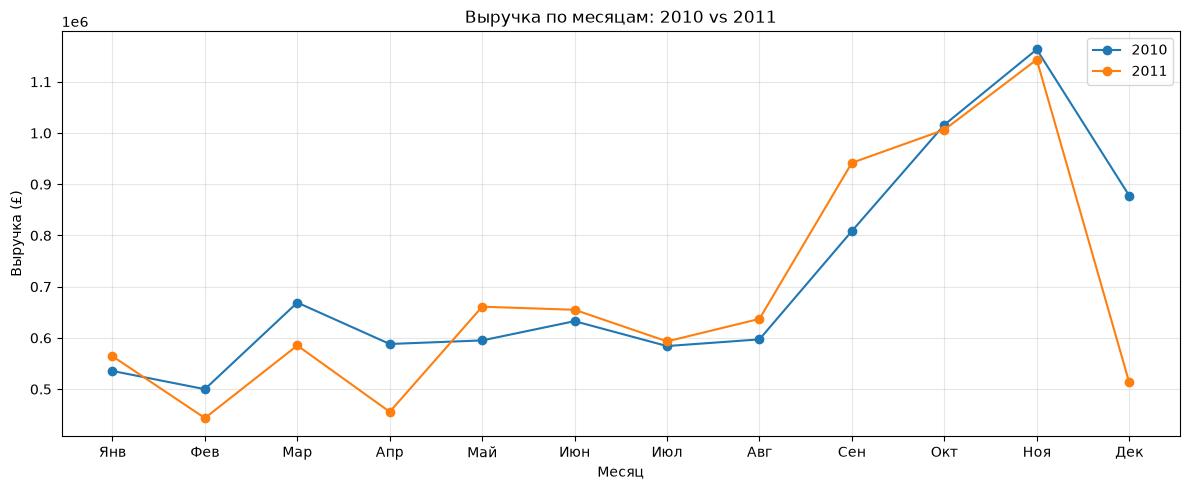

In [19]:
#Строим график
plt.figure(figsize=(12, 5))

plt.plot(range(1, 13), revenue_2010.values, label='2010', marker='o')
plt.plot(range(1, 13), revenue_2011.values, label='2011', marker='o')

plt.xlabel('Месяц')
plt.ylabel('Выручка (£)')
plt.title('Выручка по месяцам: 2010 vs 2011')
plt.legend()
plt.xticks(range(1, 13), ['Янв','Фев','Мар','Апр','Май','Июн',
                           'Июл','Авг','Сен','Окт','Ноя','Дек'])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
customer_top = df_clean.groupby('Customer ID')['Revenue'].sum()
customer_top = customer_top.sort_values(ascending=False)
customer_top.head(10)

Customer ID
18102    608821.65
14646    526751.52
14156    305228.63
14911    284044.61
17450    246973.09
13694    196482.81
17511    175603.55
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64

In [21]:
total_revenue = df_clean['Revenue'].sum()
top10_revenue = customer_top.head(10).sum()

print(f"Общая выручка:       £ {total_revenue:,.0f}")
print(f"Топ-10 клиентов:     £ {top10_revenue:,.0f}")
print(f"Доля топ-10:           {top10_revenue/total_revenue*100:.1f}%")

Общая выручка:       £ 17,448,683
Топ-10 клиентов:     £ 2,803,554
Доля топ-10:           16.1%


In [22]:
total_revenue = customer_top.sum()
total_customers = len(customer_top)

# Считаем накопленную долю
cumulative = customer_top.cumsum() / total_revenue * 100

# Сколько клиентов дают 80% выручки
customers_80 = (cumulative < 80).sum()

print(f"Всего клиентов: {total_customers:,}")
print(f"Клиентов дающих 80% выручки: {customers_80:,}")
print(f"Это {customers_80/total_customers*100:.1f}% от базы")

Всего клиентов: 5,853
Клиентов дающих 80% выручки: 1,351
Это 23.1% от базы


In [23]:
# Топ по количеству проданных единиц
top_quantity = df_clean.groupby('StockCode')['Quantity'].sum()
top_quantity = top_quantity.sort_values(ascending=False)
print('Топ по количеству проданных единиц')
print(top_quantity.head(10))


Топ по количеству проданных единиц
StockCode
84077     109169
85099B     94983
85123A     93697
21212      91263
23843      80995
84879      79913
22197      77971
23166      77916
17003      71129
21977      55270
Name: Quantity, dtype: int64


In [24]:
# Топ по выручке  
top_revenue = df_clean.groupby('StockCode')['Revenue'].sum()
product_top = top_revenue.sort_values(ascending=False)
print('# Топ по выручке')
print(product_top.head(10))

# Топ по выручке
StockCode
22423     286486.30
85123A    252227.81
85099B    170616.68
23843     168469.60
84879     127074.17
47566     103880.23
23166      81416.73
22086      79594.33
79321      72860.14
22386      68439.19
Name: Revenue, dtype: float64


In [25]:
total_revenue
total_product = df_clean['StockCode'].nunique()

# Считаем накопленную долю
cumulative_product = product_top.cumsum() / total_revenue * 100

# Сколько товаров дают 80% выручки
customers_product_80 = (cumulative_product < 80).sum()

print(f"Всего товаров: {total_product:,}")
print(f"Товаров дающих 80% выручки: {customers_product_80:,}")
print(f"Это {customers_product_80/total_product*100:.1f}% от базы")

Всего товаров: 4,625
Товаров дающих 80% выручки: 998
Это 21.6% от базы


In [26]:
top_product_for_revenue = product_top.head(10).index.intersection(top_quantity.head().index)

print(f'Топ 3 товара {', '.join(top_product_for_revenue)}')


Топ 3 товара 85123A, 85099B, 23843


***

# Сегментация клиентов: RFM-анализ
### 📋 Три ключевых показателя
| Параметр | Название | Суть | Основной вопрос |
| :--- | :--- | :--- | :--- |
| **R** | **Recency** | Давность | Как давно клиент совершил последнюю покупку? |
| **F** | **Frequency** | Частота | Сколько покупок совершил клиент за все время? |
| **M** | **Monetary** | Деньги | Какова общая сумма трат этого клиента? |



In [27]:
rfm = df_clean.groupby('Customer ID').agg(
    last_purchase = ('InvoiceDate', 'max'),
    frequency = ('Invoice', 'nunique'),
    monetary = ('Revenue', 'sum')
)
rfm.head(5)

,last_purchase,frequency,monetary
Customer ID,,,
12346,2011-01-18 10:01:00,12,77556.46
12347,2011-12-07 15:52:00,8,5633.32
12348,2011-09-25 13:13:00,5,1658.40
12349,2011-11-21 09:51:00,3,3678.69
12350,2011-02-02 16:01:00,1,294.40


---

### Считаем Recency (давность с последней покупки)

In [28]:
# snapshot_date 
# (дата среза) - Последний день в данных + 1

snapshot_date =  df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Дата среза <snapshot_date> : {snapshot_date:%Y-%m-%d}')

Дата среза <snapshot_date> : 2011-12-10


In [29]:
# Добавляем Recency - давность покупки в наш RFM
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# Делается скоринг с помощу разделения на группы (квантили)
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1], duplicates='drop')
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# Объединяем три балла в один RFM-сегмент
rfm['rfm_segment'] = (rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str))


rfm.head(5)

,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,rfm_segment
Customer ID,,,,,,,,
12346,2011-01-18 10:01:00,12,77556.46,326,2,5,5,255
12347,2011-12-07 15:52:00,8,5633.32,2,5,4,5,545
12348,2011-09-25 13:13:00,5,1658.40,75,3,4,4,344
12349,2011-11-21 09:51:00,3,3678.69,19,5,3,5,535
12350,2011-02-02 16:01:00,1,294.40,310,2,1,2,212


---

### 🎯 Формирование сегментов клиентов (RFM)
Для классификации базы мы используем комбинацию показателей **Recency** (Давность) и **Frequency** (Частота). Это позволяет разделить клиентов по их жизненному циклу и ценности.


| Сегмент | Условие (Score) | Описание поведения | Стратегия взаимодействия |
| :--- | :--- | :--- | :--- |
| **Champions** | `R ≥ 4, F ≥ 4` | Купили недавно и покупают часто. Самые ценные клиенты. | Награждать, просить отзывы, предлагать эксклюзив. |
| **Loyal** | `R ≥ 3, F ≥ 3` | Стабильно и регулярно совершают покупки. | Программы лояльности, кросс-продажи (Cross-sell). |
| **New Customers** | `R ≥ 4, F ≤ 2` | Совершили первую покупку совсем недавно. | Приветственные серии писем, помощь в освоении продукта. |
| **At Risk** | `R ≤ 2, F ≥ 4` | Раньше покупали часто, но давно не возвращались. | Реактивация: спецпредложения, опросы «почему ушли?». |
| **Lost** | `R ≤ 2, F ≤ 2` | Покупали редко и очень давно. Скорее всего, ушли. | Не тратить бюджет, либо слабая массовая рассылка. |
| **Potential** | `остальные` | Средние показатели, «плавающая» группа. | Попытаться перевести в разряд лояльных через акции. |


In [30]:
def rfm_lable(row):
    r = int(row['r_score'])
    f = int(row['f_score'])

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential'

rfm['segment'] = rfm.apply(rfm_lable, axis=1)

rfm.head(5)

,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,rfm_segment,segment
Customer ID,,,,,,,,,
12346,2011-01-18 10:01:00,12,77556.46,326,2,5,5,255,At Risk
12347,2011-12-07 15:52:00,8,5633.32,2,5,4,5,545,Champions
12348,2011-09-25 13:13:00,5,1658.40,75,3,4,4,344,Loyal
12349,2011-11-21 09:51:00,3,3678.69,19,5,3,5,535,Loyal
12350,2011-02-02 16:01:00,1,294.40,310,2,1,2,212,Lost


In [31]:
seg = rfm.groupby('segment').agg(
    customers=('monetary', 'size'),
    revenue=('monetary', 'sum')
)
seg['cust_share'] = (seg['customers'] / seg['customers'].sum() * 100).round(1)
seg['rev_share'] = (seg['revenue'] / seg['revenue'].sum() * 100).round(1)
print(seg.sort_values('rev_share', ascending=False))

               customers       revenue  cust_share  rev_share
segment                                                      
Champions           1473  1.208786e+07        25.2       69.3
Loyal               1212  2.467109e+06        20.7       14.1
At Risk              360  1.149911e+06         6.2        6.6
Potential            848  6.940417e+05        14.5        4.0
Lost                1509  6.303980e+05        25.8        3.6
New Customers        451  4.193687e+05         7.7        2.4


## Вывод

**Данные и качество.** Исходный датасет содержал 1,067,371 строку за период 2009-12-01 — 2011-12-09 (738 дней). После очистки (удаление возвратов, строк без Customer ID, некорректных Quantity/Price и служебных StockCode вроде POST, M, ADJUST) осталось 802,932 строки (75.2%) — это данные о 5,853 клиентах и 4,625 товарах на общую выручку £17,448,683.

**Сезонность.** Выручка стабильно растёт к концу года: пик приходится на сентябрь–ноябрь (подготовка к Рождеству), после чего в декабре и особенно в январе–феврале следует спад. Динамика 2010 и 2011 годов практически повторяет друг друга, что говорит о выраженной и предсказуемой сезонности бизнеса.

**Концентрация выручки (принцип Парето).**
- По клиентам: топ-10 клиентов дают лишь 16.1% выручки, но 80% выручки формируют всего 23.1% клиентской базы (1,351 из 5,853) — классическое проявление принципа 80/20.
- По товарам: 80% выручки обеспечивают 21.6% товарного ассортимента (998 из 4,625 SKU), лидеры — 85123A, 85099B и 23843.

**RFM-сегментация.** Разбивка клиентов по Recency/Frequency/Monetary показала резкий дисбаланс ценности сегментов:
- **Champions** — 25.2% клиентов, но 69.3% выручки. Это ядро бизнеса, требующее удержания и VIP-обслуживания.
- **Loyal** — 20.7% клиентов / 14.1% выручки — стабильный сегмент-кандидат на рост через кросс-продажи.
- **At Risk** (6.2% / 6.6%) и **Lost** (25.8% / 3.6%) — почти четверть базы фактически потеряна для бизнеса, но приносит лишь 3.6% выручки, то есть их отток некритичен для дохода, хотя часть можно попытаться реактивировать.
- **Potential** (14.5% / 4.0%) и **New Customers** (7.7% / 2.4%) — точки роста: с ними стоит работать через акции и онбординг, чтобы перевести в Loyal/Champions.

**Практический вывод.** Бизнес сильно зависит от узкой группы клиентов (Champions) и ограниченного набора товаров — риск концентрации высок: потеря нескольких ключевых клиентов или товарных позиций способна заметно ударить по выручке. Приоритетные направления: удержание Champions и Loyal (программы лояльности, персональные предложения), реактивация At Risk, где ещё есть потенциал, и не распыление бюджета на сегмент Lost. Сезонность также стоит учитывать при планировании закупок и маркетинговых кампаний, усиливая их к осеннему пику спроса.
